In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def cal_Obesity(BMI):
    return abs((BMI/22-1)*100)

In [19]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)
df['WaterVar']=df['Total Body Water (TBW)']-df['Extracellular Water (ECW)']-df['Intracellular Water (ICW)']
df

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D,WaterVar
0,0,50,0,0,0,0,0,0,185,92.8,...,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0,0.000000e+00
1,0,47,0,1,0,0,0,0,176,94.5,...,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0,0.000000e+00
2,0,61,0,0,0,0,0,0,171,91.1,...,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2,0.000000e+00
3,0,41,0,0,0,0,0,0,168,67.7,...,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4,0.000000e+00
4,0,42,0,0,0,0,0,0,178,89.6,...,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,49,0,0,0,0,0,0,178,88.8,...,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3,-4.000000e-01
315,1,31,1,0,0,0,0,0,157,53.4,...,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0,0.000000e+00
316,1,58,0,0,0,0,0,0,172,96.6,...,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7,3.552714e-15
317,1,37,1,0,0,0,0,0,177,88.4,...,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3,3.552714e-15


In [5]:
df.isnull().values.any()

np.False_

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

In [7]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Gallstone Status,319.0,0.495298,0.500763,0.00,0.000,0.000000,1.000,1.00
Age,319.0,48.068966,12.114558,20.00,38.500,49.000000,56.000,96.00
Gender,319.0,0.492163,0.500724,0.00,0.000,0.000000,1.000,1.00
Comorbidity,319.0,0.335423,0.517340,0.00,0.000,0.000000,1.000,3.00
Coronary Artery Disease (CAD),319.0,0.037618,0.190568,0.00,0.000,0.000000,0.000,1.00
Hypothyroidism,319.0,0.028213,0.165841,0.00,0.000,0.000000,0.000,1.00
Hyperlipidemia,319.0,0.025078,0.156609,0.00,0.000,0.000000,0.000,1.00
Diabetes Mellitus (DM),319.0,0.134796,0.342042,0.00,0.000,0.000000,0.000,1.00
Height,319.0,167.156740,10.053030,145.00,159.500,168.000000,175.000,191.00
Weight,319.0,80.564890,15.709069,42.90,69.600,78.800000,91.250,143.50


In [8]:
# [GROUP 1] Demographic & Anthropometric Baselines
# Method: Electronic Health Records (EHR) & Standard Physical Measurement.
# - Demographics: Age (Years) and Gender (Binary: 0=Male, 1=Female).
# - Anthropometry: Height (cm), Weight (kg), and Body Mass Index (kg/m²).
df_demographic = df[[
    'Age',
    'Gender',
    'Height',
    'Weight',
    'Body Mass Index (BMI)'
]].copy()

# [GROUP 2] Clinical History
# Method: Medical History Review (Binary Classification).
# - Comorbidities: Presence of any comorbidity condition (1=Yes, 0=No).
# - Specific Conditions: Diagnosed history of CAD, Hypothyroidism, etc.
df_comorbidities = df[[
    'Comorbidity',
    'Coronary Artery Disease (CAD)',
    'Hypothyroidism',
    'Hyperlipidemia',
    'Diabetes Mellitus (DM)'
]].copy()

# [GROUP 3] Bioelectrical Impedance Analysis (BIA) & Imaging
# Method A (Composition): "Tanita MC780" Body Composition Analyzer[cite: 74].
# - Protocol: Non-invasive electrical resistance measurement of tissues.
# - Metrics: TBW (kg), Fat (%), Muscle (kg), Bone (kg).
#
# Method B (Liver Fat): "Ultrasonography"[cite: 77].
# - Hepatic Fat Accumulation (HFA): Diagnosed via imaging, not BIA.
df_bioimpedance = df[[
    'Total Body Water (TBW)',
    'Extracellular Water (ECW)',
    'Intracellular Water (ICW)',
    'Extracellular Fluid/Total Body Water (ECF/TBW)',
    'Total Body Fat Ratio (TBFR) (%)',
    'Lean Mass (LM) (%)',
    'Body Protein Content (Protein) (%)',
    'Visceral Fat Rating (VFR)',
    'Bone Mass (BM)',
    'Muscle Mass (MM)',
    'Obesity (%)',
    'Total Fat Content (TFC)',
    'Visceral Fat Area (VFA)',
    'Visceral Muscle Area (VMA) (Kg)',
    'Hepatic Fat Accumulation (HFA)' # Note: Via Ultrasound, grouped here for "Body Comp" context.
]].copy()

# [GROUP 4] Laboratory & Metabolic Markers
# Method: Clinical "Blood Tests" routinely gauged in laboratories.
# Lipid/Glucose: Measured in mg/dL (Glucose, Cholesterol, LDL, HDL, Triglycerides).
# Liver Enzymes: Measured in U/L (AST, ALT, ALP).
# Renal Function: Creatinine (mg/dL) and GFR (ml/seconds).
# Specialized: CRP (mg/L), Hemoglobin (g/dL), and vitamin D (ng/mL).
df_laboratory = df[[
    'Glucose',
    'Total Cholesterol (TC)',
    'Low Density Lipoprotein (LDL)',
    'High Density Lipoprotein (HDL)',
    'Triglyceride',
    'Aspartat Aminotransferaz (AST)',
    'Alanin Aminotransferaz (ALT)',
    'Alkaline Phosphatase (ALP)',
    'Creatinine',
    'Glomerular Filtration Rate (GFR)',
    'C-Reactive Protein (CRP)',
    'Hemoglobin (HGB)',
    'Vitamin D'
]].copy()

In [9]:
data_groups = {
    "Demographic": df_demographic,
    "Clinical History": df_comorbidities,
    "Bioimpedance & Imaging": df_bioimpedance,
    "Laboratory": df_laboratory
}
print(f"{'GROUP NAME':<25} | {'SHAPE (Rows, Cols)'}\n")
for name, data in data_groups.items():
    print(f"{name:<25} | {data.shape}")

GROUP NAME                | SHAPE (Rows, Cols)

Demographic               | (319, 5)
Clinical History          | (319, 5)
Bioimpedance & Imaging    | (319, 15)
Laboratory                | (319, 13)


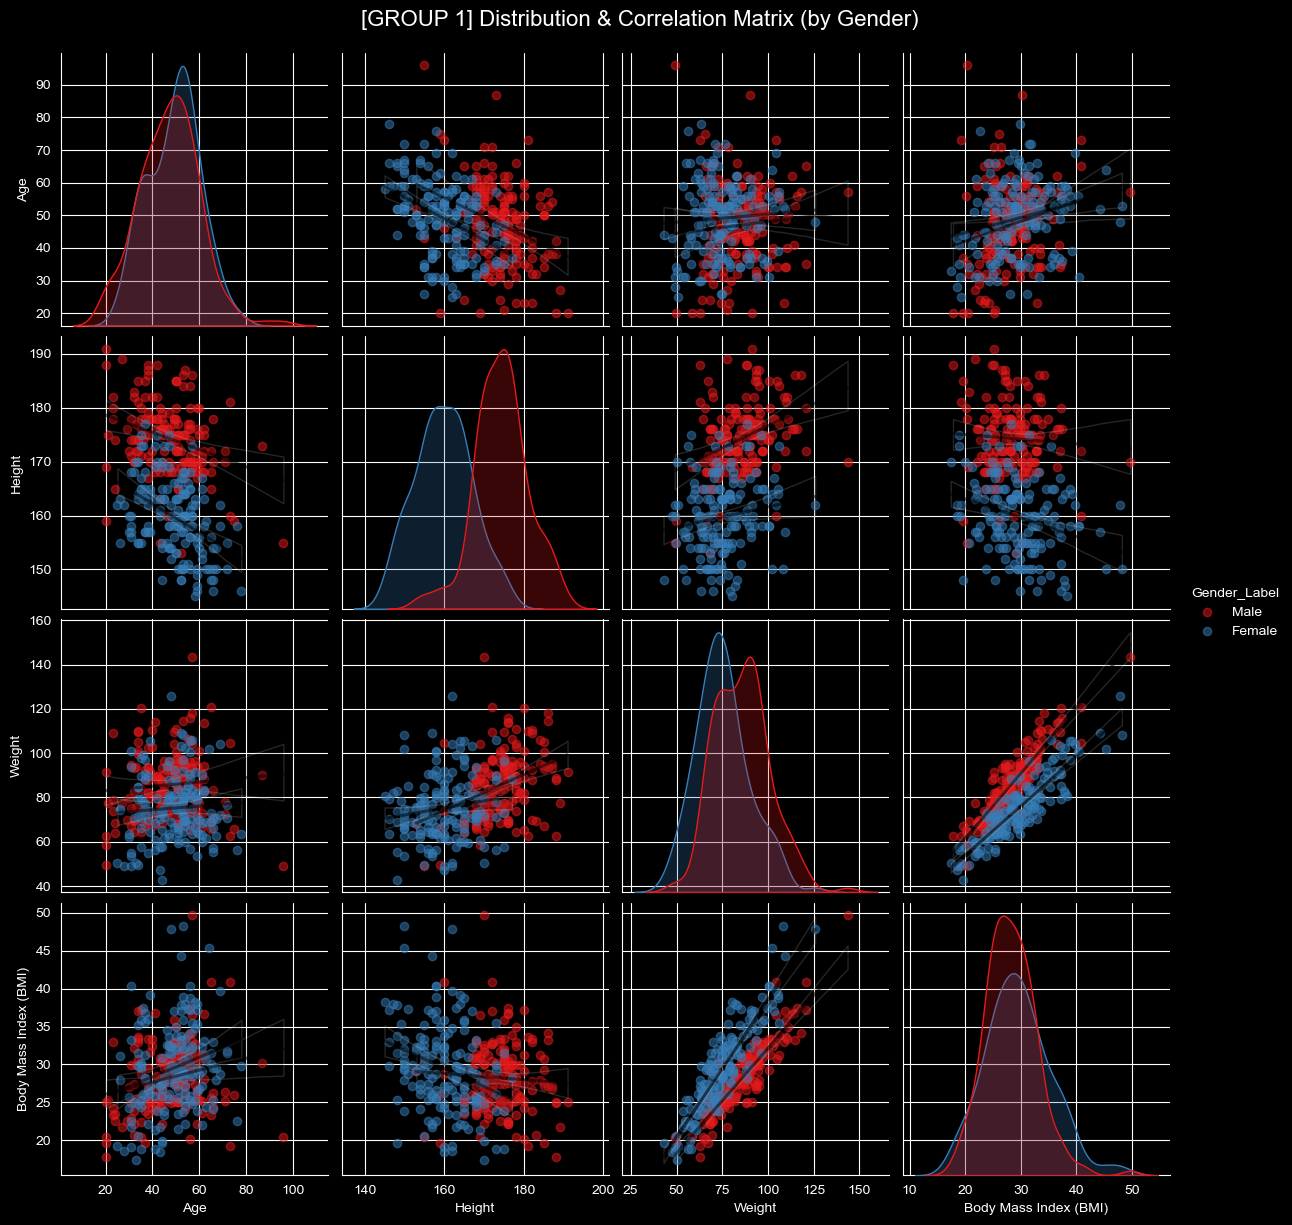

In [10]:
df_demographic['Gender_Label'] = df_demographic['Gender'].map({0: 'Male', 1: 'Female'})
g = sns.pairplot(
    df_demographic,
    hue='Gender_Label',
    vars=['Age', 'Height', 'Weight', 'Body Mass Index (BMI)'], # Exclude 'Gender' column from the axis
    kind='reg',
    diag_kind='kde',
    palette='Set1',
    plot_kws={'scatter_kws': {'alpha': 0.5}, 'line_kws': {'color': 'black', 'alpha': 0.5}}, # Make points semi-transparent to see overlap
    height=3 # Size of each subplot
)
g.fig.suptitle('[GROUP 1] Distribution & Correlation Matrix (by Gender)', y=1.02, fontsize=16)
plt.show()

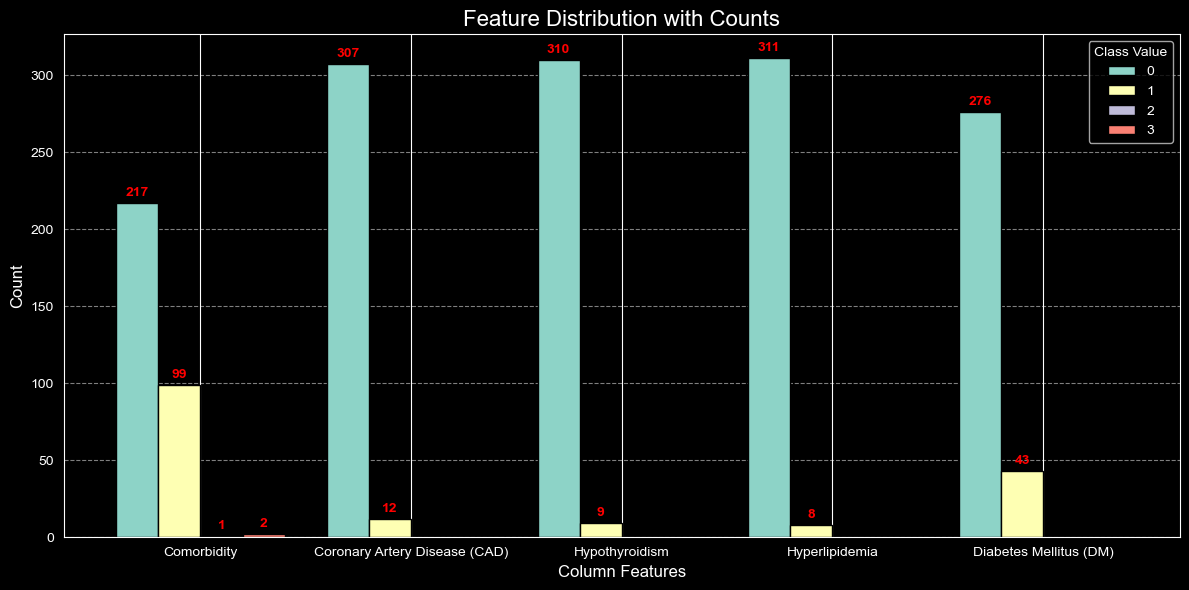

In [16]:
# 2. Transform the data for plotting
# "apply(pd.Series.value_counts)" counts values for every column independently.
# It aligns them on the index (0, 1, 2, 3).
# Binary columns will have NaNs for indices 2 and 3, which we fill with 0.
counts_df = df_comorbidities.apply(pd.Series.value_counts).fillna(0)

# Transpose (.T) moves Columns to the X-axis and Indices (0,1,2,3) to the Legend/Bars
plot_data = counts_df.T

fig, ax = plt.subplots(figsize=(12, 6))
plot_data.plot(
    kind='bar',
    ax=ax,
    width=0.8,
    edgecolor='black'
)

# 4. Add Labels (Red color, integers)
# We iterate through each group of bars (containers)
for container in ax.containers:
    # Create custom labels:
    # - f'{int(h)}': Formats the height as an integer
    # - if h > 0 else '': Hides the label if count is 0 (keeps binary cols clean)
    labels = [f'{int(h)}' if h > 0 else '' for h in container.datavalues]

    ax.bar_label(
        container,
        labels=labels,       # Use our custom labels
        label_type='edge',   # Place label on top of bar
        color='red',
        fontsize=10,
        weight='bold',
        padding=3
    )

# 5. Styling
plt.title('Feature Distribution with Counts', fontsize=16)
plt.xlabel('Column Features', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Class Value')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

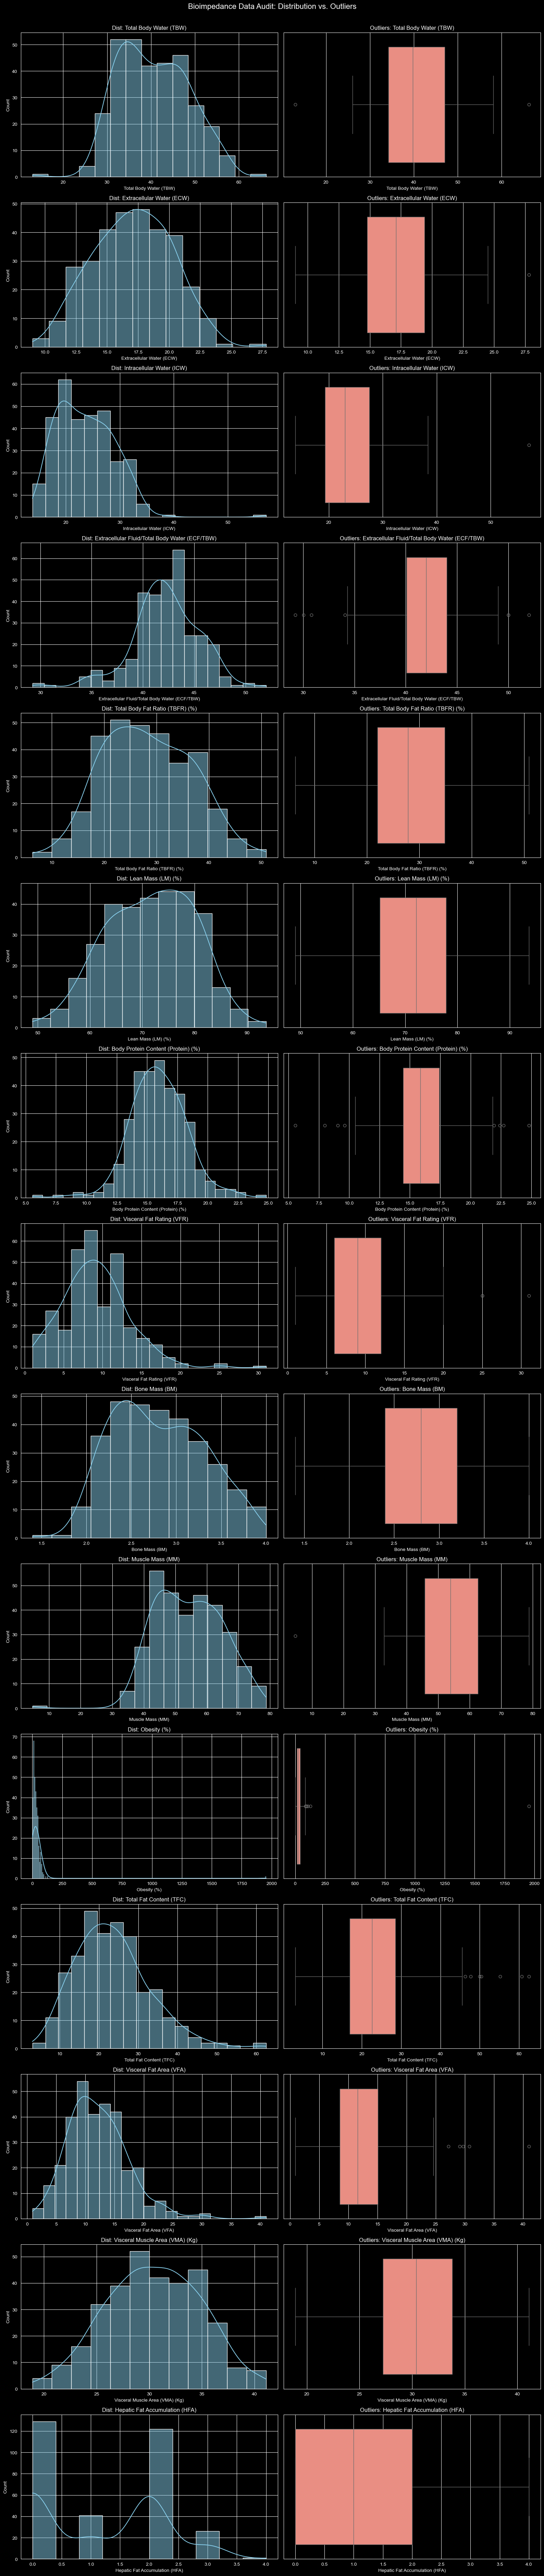

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ASSUMPTION: 'df_bioimpedance' is already loaded as per your snippet.

def audit_bioimpedance_features(df, features):
    """
    Generates a Distribution + Boxplot grid for Bioimpedance features.
    Design: Commercial (Robust to NaNs, dynamic layout).
    """
    # 1. Setup Canvas
    n_features = len(features)
    fig, axes = plt.subplots(n_features, 2, figsize=(16, 5 * n_features))
    fig.suptitle('Bioimpedance Data Audit: Distribution vs. Outliers', fontsize=16, y=1.002)

    for i, col in enumerate(features):
        # 2. Safety Check (Observability)
        if col not in df.columns:
            print(f"[WARN] Column '{col}' not found. Skipping.")
            continue

        # 3. Plotting Logic
        # Left: Histogram/KDE (Shape of data)
        if pd.api.types.is_numeric_dtype(df[col]):
            sns.histplot(data=df, x=col, kde=True, ax=axes[i, 0], color='skyblue')
            axes[i, 0].set_title(f'Dist: {col}')

            # Right: Boxplot (Outlier detection)
            sns.boxplot(data=df, x=col, ax=axes[i, 1], color='salmon')
            axes[i, 1].set_title(f'Outliers: {col}')
        else:
            # Fallback for Categorical (e.g., HFA labels)
            sns.countplot(data=df, x=col, ax=axes[i, 0], palette='viridis')
            axes[i, 0].set_title(f'Count: {col}')
            axes[i, 1].text(0.5, 0.5, 'Categorical (No Boxplot)', ha='center', va='center')

    plt.tight_layout()
    return fig

# Define your list
target_cols = [
    'Total Body Water (TBW)', 'Extracellular Water (ECW)', 'Intracellular Water (ICW)',
    'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Total Body Fat Ratio (TBFR) (%)',
    'Lean Mass (LM) (%)', 'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)',
    'Bone Mass (BM)', 'Muscle Mass (MM)', 'Obesity (%)', 'Total Fat Content (TFC)',
    'Visceral Fat Area (VFA)', 'Visceral Muscle Area (VMA) (Kg)', 'Hepatic Fat Accumulation (HFA)'
]

# Run
audit_bioimpedance_features(df_bioimpedance, target_cols)
plt.show()

In [ ]:
df['CalculatedObesityDegree'] = df['Body Mass Index (BMI)'].apply(cal_Obesity)

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Setup the figure (2 Subplots)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: BOXPLOT (The Detection) ---
# Shows the distribution and the massive outlier
ax[0].boxplot(df['Obesity (%)'], vert=False, patch_artist=True)
ax[0].set_title('Distribution of Measured Obesity % (Outlier Detection)')
ax[0].set_xlabel('Obesity (%)')

# --- PLOT 2: SCATTER WITH STRAIGHT LINE (The Proof) ---
# X-axis = Your Formula (Calculated)
# Y-axis = The Sensor Data (Obesity %)
ax[1].scatter(df['CalculatedObesityDegree'], df['Obesity (%)'],
              alpha=0.6, label='Data Points')

# Add the "Straight Line" (Perfect Match Line y=x)
# If points fall on this line, Calculated == Measured.
# The outlier will be visibly far away from this line.
lims = [
    np.min([ax[1].get_xlim(), ax[1].get_ylim()]),  # min of both axes
    np.max([ax[1].get_xlim(), ax[1].get_ylim()]),  # max of both axes
]
ax[1].plot(lims, lims, 'r--', alpha=0.75, linewidth=2, label='Perfect Match (y=x)')

ax[1].set_title('Correlation: Calculated vs. Measured')
ax[1].set_xlabel('Calculated Obesity Degree')
ax[1].set_ylabel('Measured Obesity (%)')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: 'CalculatedObesityDegree'

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. DEFINE PHYSICS LOGIC ---
# Formula: Obesity = |(BMI/22 - 1) * 100|
# Max possible Human BMI is ~204. Let's be conservative and say 250.
max_possible_bmi = 250
max_possible_obesity = abs((max_possible_bmi / 22 - 1) * 100) # ~1036%

# --- 2. CLEAN THE DATA ---
# Identify data that breaks the laws of physics
error_mask = df['Obesity (%)'] > max_possible_obesity

# Fix the errors using the Calculated value
df.loc[error_mask, 'Obesity (%)'] = df.loc[error_mask, 'CalculatedObesityDegree']

# --- 3. CALCULATE SCORE ---
# Calculate Pearson Correlation (R) on the final cleaned data
r_score = df['CalculatedObesityDegree'].corr(df['Obesity (%)'])
r_squared = r_score ** 2

# --- 4. VISUALIZE WITH SCORE ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the Validated Data
ax.scatter(df['CalculatedObesityDegree'], df['Obesity (%)'],
           alpha=0.6, color='teal', label='Validated Data')

# Plot the "Perfect Match" Reference Line
lims = [0, df['Obesity (%)'].max() * 1.05]
ax.plot(lims, lims, 'r--', linewidth=2, label='Theoretical Match (y=x)')

# --- THE ADDITION: DISPLAY R SCORE ON PLOT ---
# We place a text box in the top-left corner
stats_text = (f"Statistical Proof:\n"
              f"R = {r_score:.4f}\n"
              f"R² = {r_squared:.4f}")

# bbox props creates a nice white box behind the text so it's readable
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Labels and Titles
ax.set_title(f'Final Validation: Calculated vs. Measured (Fixed {error_mask.sum()} Errors)')
ax.set_xlabel('Calculated Obesity Degree (Formula)')
ax.set_ylabel('Measured Obesity Degree')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.show()